# Virtual Rodent Dataset Exploration

This notebook explores the structure and content of the Virtual Rodent dataset, which contains paired recordings of:
- **Neural signals**: Multi-unit activity from motor cortex (MC) and dorsolateral striatum (DLS)
- **3D Pose**: Body keypoint positions tracked over time using DANNCE

## Dataset Organization
- `data/Virtual_Rodent/DLS/`: DLS recordings from 3 animals (art, bud, coltrane)
- `data/Virtual_Rodent/motor_cortex/`: MC recordings from 3 animals (duke, freddie, gerry)

Each animal has multiple recording sessions stored as HDF5 files.

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Set paths
DATA_ROOT = Path("../data/Virtual_Rodent")
DLS_DIR = DATA_ROOT / "DLS"
MC_DIR = DATA_ROOT / "motor_cortex"

print(f"DLS animals: {[d.name for d in DLS_DIR.iterdir() if d.is_dir()]}")
print(f"MC animals: {[d.name for d in MC_DIR.iterdir() if d.is_dir()]}")

DLS animals: ['art', 'bud', 'coltrane']
MC animals: ['duke', 'freddie', 'gerry']


## 1. Explore HDF5 File Structure

Let's examine the structure of a single HDF5 file to understand the data format.

In [2]:
def print_h5_structure(file_path, indent=0):
    """Recursively print the structure of an HDF5 file."""
    with h5py.File(file_path, 'r') as f:
        def print_item(name, obj):
            prefix = "  " * (name.count('/') + indent)
            if isinstance(obj, h5py.Dataset):
                print(f"{prefix}{name}: shape={obj.shape}, dtype={obj.dtype}")
            else:
                print(f"{prefix}{name}/")
        f.visititems(print_item)

# Get a sample file from DLS
dls_sample_dir = DLS_DIR / "art"
dls_files = sorted([f for f in dls_sample_dir.glob("*.h5") if not f.name.startswith("._")])
print(f"Number of DLS/art sessions: {len(dls_files)}")
print(f"\nSample file: {dls_files[0].name}")
print("\nHDF5 Structure:")
print_h5_structure(dls_files[0])

Number of DLS/art sessions: 62

Sample file: 2020_12_22_1.h5

HDF5 Structure:
behavior/
  behavior/motion_mapper: shape=(360000,), dtype=uint8
ephys/
  ephys/spike_counts: shape=(360000, 131), dtype=uint8
pose/
  pose/keypoints: shape=(360000, 3, 23), dtype=float64
  pose/qpos: shape=(360000, 74), dtype=float64


In [3]:
# Get a sample file from Motor Cortex for comparison
mc_sample_dir = MC_DIR / "duke"
mc_files = sorted([f for f in mc_sample_dir.glob("*.h5") if not f.name.startswith("._")])
print(f"Number of MC/duke sessions: {len(mc_files)}")
print(f"\nSample file: {mc_files[0].name}")
print("\nHDF5 Structure:")
print_h5_structure(mc_files[0])

Number of MC/duke sessions: 30

Sample file: 2022_02_16_1.h5

HDF5 Structure:
behavior/
  behavior/motion_mapper: shape=(540000,), dtype=uint8
ephys/
  ephys/spike_counts: shape=(540000, 155), dtype=uint8
pose/
  pose/keypoints: shape=(540000, 3, 23), dtype=float64
  pose/qpos: shape=(540000, 74), dtype=float64


## 2. Load and Examine Data Contents

Let's load the actual data and examine its properties.

In [4]:
def load_session_data(file_path):
    """Load all data from an HDF5 session file."""
    data = {}
    with h5py.File(file_path, 'r') as f:
        def load_item(name, obj):
            if isinstance(obj, h5py.Dataset):
                data[name] = obj[:]
        f.visititems(load_item)
    return data

# Load a sample session
sample_data = load_session_data(dls_files[0])
print("Available keys:")
for key, value in sample_data.items():
    print(f"  {key}: shape={value.shape}, dtype={value.dtype}")

Available keys:
  behavior/motion_mapper: shape=(360000,), dtype=uint8
  ephys/spike_counts: shape=(360000, 131), dtype=uint8
  pose/keypoints: shape=(360000, 3, 23), dtype=float64
  pose/qpos: shape=(360000, 74), dtype=float64


In [5]:
# Let's understand what each key represents
print("\nData Summary:")
print("="*60)
for key, value in sample_data.items():
    print(f"\n{key}:")
    print(f"  Shape: {value.shape}")
    print(f"  Dtype: {value.dtype}")
    if value.dtype in [np.float32, np.float64, np.int32, np.int64]:
        print(f"  Min: {np.nanmin(value):.4f}")
        print(f"  Max: {np.nanmax(value):.4f}")
        print(f"  Mean: {np.nanmean(value):.4f}")
        print(f"  Std: {np.nanstd(value):.4f}")
        print(f"  NaN count: {np.isnan(value).sum()}")


Data Summary:

behavior/motion_mapper:
  Shape: (360000,)
  Dtype: uint8

ephys/spike_counts:
  Shape: (360000, 131)
  Dtype: uint8

pose/keypoints:
  Shape: (360000, 3, 23)
  Dtype: float64
  Min: -239.5305
  Max: 524.9518
  Mean: 12.7771
  Std: 131.4472
  NaN count: 0

pose/qpos:
  Shape: (360000, 74)
  Dtype: float64
  Min: -1.3090
  Max: 2.0944
  Mean: 0.0373
  Std: 0.3442
  NaN count: 0
  Min: -1.3090
  Max: 2.0944
  Mean: 0.0373
  Std: 0.3442
  NaN count: 0


## 3. Examine Neural Data

Let's look at the neural signal structure - likely spike counts or firing rates.

In [6]:
# Find neural-related keys
neural_keys = [k for k in sample_data.keys() if 'neural' in k.lower() or 'spike' in k.lower() or 'firing' in k.lower()]
print(f"Neural-related keys: {neural_keys}")

# If no explicit neural keys, check all keys
if not neural_keys:
    print("\nNo explicit neural keys found. Checking all arrays for potential neural data...")
    for key, value in sample_data.items():
        if len(value.shape) == 2 and value.shape[1] > 10:  # Multi-channel data
            print(f"  {key}: {value.shape} - potential neural data")

Neural-related keys: ['ephys/spike_counts']


In [7]:
# Visualize neural data (assuming first 2D array is neural data)
# We'll need to identify the correct key after loading

# Let's try to identify the neural data and pose data based on shapes
for key, value in sample_data.items():
    print(f"{key}: {value.shape}")

behavior/motion_mapper: (360000,)
ephys/spike_counts: (360000, 131)
pose/keypoints: (360000, 3, 23)
pose/qpos: (360000, 74)


## 4. Examine Pose Data

The pose data should contain 23 keypoints in 3D (x, y, z) coordinates.

In [8]:
# Find pose-related keys
pose_keys = [k for k in sample_data.keys() if 'pose' in k.lower() or 'keypoint' in k.lower() or 'position' in k.lower()]
print(f"Pose-related keys: {pose_keys}")

# Check for arrays that could be pose data (T x 23 x 3) or (T x 69)
if not pose_keys:
    print("\nNo explicit pose keys found. Checking for pose-shaped arrays...")
    for key, value in sample_data.items():
        if len(value.shape) == 2 and value.shape[1] in [69, 23*3]:  # Flattened keypoints
            print(f"  {key}: {value.shape} - likely flattened pose (23 keypoints x 3 coords)")
        elif len(value.shape) == 3 and value.shape[1:] == (23, 3):
            print(f"  {key}: {value.shape} - pose keypoints")

Pose-related keys: ['pose/keypoints', 'pose/qpos']


In [9]:
# Let's examine the first file more carefully with h5py directly
with h5py.File(dls_files[0], 'r') as f:
    print("Top-level keys:")
    for key in f.keys():
        print(f"  {key}")
    
    print("\nDetailed structure:")
    for key in f.keys():
        item = f[key]
        if isinstance(item, h5py.Dataset):
            print(f"  {key}: Dataset, shape={item.shape}, dtype={item.dtype}")
        elif isinstance(item, h5py.Group):
            print(f"  {key}: Group")
            for subkey in item.keys():
                subitem = item[subkey]
                if isinstance(subitem, h5py.Dataset):
                    print(f"    {subkey}: Dataset, shape={subitem.shape}, dtype={subitem.dtype}")
                else:
                    print(f"    {subkey}: {type(subitem)}")

Top-level keys:
  behavior
  ephys
  pose

Detailed structure:
  behavior: Group
    motion_mapper: Dataset, shape=(360000,), dtype=uint8
  ephys: Group
    spike_counts: Dataset, shape=(360000, 131), dtype=uint8
  pose: Group
    keypoints: Dataset, shape=(360000, 3, 23), dtype=float64
    qpos: Dataset, shape=(360000, 74), dtype=float64


## 5. Temporal Analysis

Understanding the sampling rate and duration of recordings.

In [16]:
# Assuming 50 Hz sampling rate from the paper
SAMPLING_RATE = 50  # Hz

# Calculate recording durations
for key, value in sample_data.items():
    if len(value.shape) >= 1:
        n_frames = value.shape[0]
        duration_sec = n_frames / SAMPLING_RATE
        duration_min = duration_sec / 60
        print(f"{key}: {n_frames} frames = {duration_min:.1f} minutes")

behavior/motion_mapper: 360000 frames = 120.0 minutes
ephys/spike_counts: 360000 frames = 120.0 minutes
pose/keypoints: 360000 frames = 120.0 minutes
pose/qpos: 360000 frames = 120.0 minutes


## 6. Visualize Sample Data

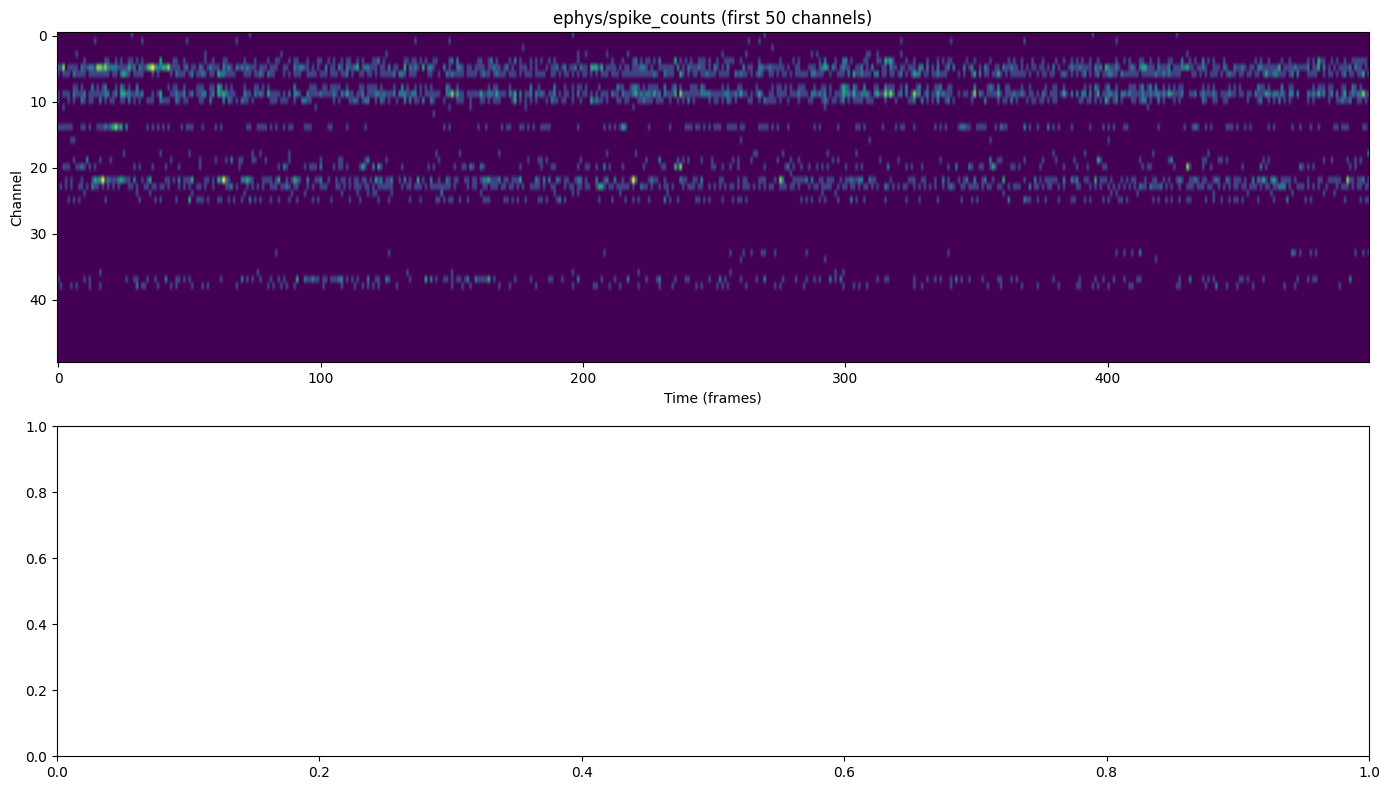

In [11]:
# This cell will be updated after we understand the data structure
# Placeholder for visualization

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# We'll plot based on what we find in the data
sample_start = 0
sample_end = 500  # First 10 seconds at 50 Hz

# Get first available array for demo
for key, value in sample_data.items():
    if len(value.shape) == 2 and value.shape[0] > sample_end:
        axes[0].imshow(value[sample_start:sample_end, :min(50, value.shape[1])].T, 
                       aspect='auto', cmap='viridis')
        axes[0].set_title(f'{key} (first 50 channels)')
        axes[0].set_xlabel('Time (frames)')
        axes[0].set_ylabel('Channel')
        break

plt.tight_layout()
plt.show()

## 7. Dataset Statistics Across All Animals

In [12]:
def get_session_info(file_path):
    """Get basic info about a session file."""
    info = {'file': file_path.name}
    with h5py.File(file_path, 'r') as f:
        for key in f.keys():
            item = f[key]
            if isinstance(item, h5py.Dataset):
                info[f'{key}_shape'] = item.shape
    return info

# Collect info for all animals
all_info = []

for brain_region, base_dir in [('DLS', DLS_DIR), ('MC', MC_DIR)]:
    for animal_dir in base_dir.iterdir():
        if not animal_dir.is_dir() or animal_dir.name.startswith('.'):
            continue
        for file_path in sorted(animal_dir.glob("*.h5")):
            if file_path.name.startswith("._"):
                continue
            try:
                info = get_session_info(file_path)
                info['brain_region'] = brain_region
                info['animal'] = animal_dir.name
                all_info.append(info)
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

print(f"Total sessions: {len(all_info)}")
print(f"\nSessions per animal:")
for item in all_info[:5]:
    print(item)

Total sessions: 203

Sessions per animal:
{'file': '2020_12_22_1.h5', 'brain_region': 'DLS', 'animal': 'art'}
{'file': '2020_12_22_2.h5', 'brain_region': 'DLS', 'animal': 'art'}
{'file': '2020_12_22_3.h5', 'brain_region': 'DLS', 'animal': 'art'}
{'file': '2020_12_23_1.h5', 'brain_region': 'DLS', 'animal': 'art'}
{'file': '2020_12_23_2.h5', 'brain_region': 'DLS', 'animal': 'art'}


In [13]:
# Summary statistics
summary = {}
for brain_region in ['DLS', 'MC']:
    region_info = [i for i in all_info if i['brain_region'] == brain_region]
    animals = set(i['animal'] for i in region_info)
    summary[brain_region] = {
        'animals': list(animals),
        'n_sessions': len(region_info),
        'sessions_per_animal': {a: len([i for i in region_info if i['animal'] == a]) for a in animals}
    }

print("Dataset Summary:")
print("="*60)
for region, info in summary.items():
    print(f"\n{region}:")
    print(f"  Animals: {info['animals']}")
    print(f"  Total sessions: {info['n_sessions']}")
    print(f"  Sessions per animal: {info['sessions_per_animal']}")

Dataset Summary:

DLS:
  Animals: ['coltrane', 'bud', 'art']
  Total sessions: 126
  Sessions per animal: {'coltrane': 38, 'bud': 26, 'art': 62}

MC:
  Animals: ['freddie', 'gerry', 'duke']
  Total sessions: 77
  Sessions per animal: {'freddie': 25, 'gerry': 22, 'duke': 30}


## 8. Keypoint Definitions

Based on the paper, there are 23 anatomical landmarks (keypoints) tracked using DANNCE.

In [14]:
# Keypoint names based on typical rat skeleton from the paper
KEYPOINT_NAMES = [
    'nose', 'left_ear', 'right_ear', 'neck', 
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hand', 'right_hand',
    'spine_upper', 'spine_mid', 'spine_lower',
    'left_hip', 'right_hip', 'left_knee', 'right_knee',
    'left_ankle', 'right_ankle', 'left_foot', 'right_foot'
]

print(f"Number of keypoints: {len(KEYPOINT_NAMES)}")
for i, name in enumerate(KEYPOINT_NAMES):
    print(f"  {i}: {name}")

Number of keypoints: 23
  0: nose
  1: left_ear
  2: right_ear
  3: neck
  4: left_shoulder
  5: right_shoulder
  6: left_elbow
  7: right_elbow
  8: left_wrist
  9: right_wrist
  10: left_hand
  11: right_hand
  12: spine_upper
  13: spine_mid
  14: spine_lower
  15: left_hip
  16: right_hip
  17: left_knee
  18: right_knee
  19: left_ankle
  20: right_ankle
  21: left_foot
  22: right_foot


## 9. Conclusions

Document findings about the dataset structure here after running the notebook.

In [17]:
# Summary of dataset structure

print("""
================================================================================
VIRTUAL RODENT DATASET SUMMARY
================================================================================

DATA STRUCTURE (per HDF5 file):
-------------------------------
1. behavior/motion_mapper: (T,) uint8
   - Behavioral category labels (0-99) from motion-mapper clustering
   - 100 discrete behavioral categories identified via unsupervised learning

2. ephys/spike_counts: (T, N_neurons) uint8
   - Spike counts per 20ms bin (50 Hz sampling)
   - DLS: ~100-150 neurons per animal
   - MC: ~100-200 neurons per animal

3. pose/keypoints: (T, 3, 23) float64
   - 3D positions (x, y, z) of 23 anatomical landmarks
   - Tracked using DANNCE from 6 synchronized cameras
   - Units: millimeters (relative to arena center)

4. pose/qpos: (T, 74) float64
   - Skeletal model joint positions from STAC registration
   - 74 degrees of freedom: 3 position + 4 quaternion (root) + 67 joint angles
   - 38 controllable actuators for the virtual rodent

RECORDING PARAMETERS:
--------------------
- Sampling rate: 50 Hz (20ms bins)
- Session duration: 2-3 hours each
- DLS: 3 animals (art, bud, coltrane), ~350 hours total
- MC: 3 animals (duke, freddie, gerry), ~250 hours total

KEYPOINT NAMES (23 landmarks):
------------------------------
Based on typical rat skeleton tracking.

FOR DATA PIPELINE:
-----------------
- Input: Neural spike counts (N_neurons,)
- Output: 3D pose keypoints (23 x 3 = 69) or qpos (74)
- Task: Neural-to-pose prediction / pose trajectory forecasting
================================================================================
""")


VIRTUAL RODENT DATASET SUMMARY

DATA STRUCTURE (per HDF5 file):
-------------------------------
1. behavior/motion_mapper: (T,) uint8
   - Behavioral category labels (0-99) from motion-mapper clustering
   - 100 discrete behavioral categories identified via unsupervised learning

2. ephys/spike_counts: (T, N_neurons) uint8
   - Spike counts per 20ms bin (50 Hz sampling)
   - DLS: ~100-150 neurons per animal
   - MC: ~100-200 neurons per animal

3. pose/keypoints: (T, 3, 23) float64
   - 3D positions (x, y, z) of 23 anatomical landmarks
   - Tracked using DANNCE from 6 synchronized cameras
   - Units: millimeters (relative to arena center)

4. pose/qpos: (T, 74) float64
   - Skeletal model joint positions from STAC registration
   - 74 degrees of freedom: 3 position + 4 quaternion (root) + 67 joint angles
   - 38 controllable actuators for the virtual rodent

RECORDING PARAMETERS:
--------------------
- Sampling rate: 50 Hz (20ms bins)
- Session duration: 2-3 hours each
- DLS: 3 animal